In [21]:
# ============================================================
# SETUP — Importaciones y funciones base
# (Integra ambos notebooks: detección + transformaciones)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import poisson, lognorm, iqr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
np.random.seed(42)

# ── Detección de outliers ──────────────────────────────────────

def detectar_outliers_iqr(serie, factor=1.5):
    """Detección por Rango Intercuartílico."""
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    li, ls = Q1 - factor*IQR, Q3 + factor*IQR
    return serie < li, serie > ls, li, ls

def detectar_outliers_zscore(serie, umbral=3):
    """Detección por Z-Score clásico."""
    return np.abs(stats.zscore(serie)) > umbral

def detectar_outliers_zscore_mod(serie, umbral=3.5):
    """Detección por Z-Score Modificado (robusto a outliers)."""
    mediana = serie.median()
    MAD = np.median(np.abs(serie - mediana))
    if MAD == 0:
        return pd.Series([False]*len(serie), index=serie.index)
    return 0.6745 * np.abs(serie - mediana) / MAD > umbral

def resumen_outliers(serie, nombre='Variable'):
    """Reporte comparativo de todos los métodos de detección."""
    _, out_iqr, li, ls = detectar_outliers_iqr(serie)
    out_z  = detectar_outliers_zscore(serie)
    out_zm = detectar_outliers_zscore_mod(serie)
    p99    = serie.quantile(0.99)
    print(f"\n{'='*55}")
    print(f"  📊 Resumen de Outliers: {nombre}")
    print(f"{'='*55}")
    print(f"  N total          : {len(serie):,}")
    print(f"  Media            : {serie.mean():,.2f}")
    print(f"  Mediana          : {serie.median():,.2f}")
    print(f"  Desv. Estándar   : {serie.std():,.2f}")
    print(f"  Mín / Máx        : {serie.min():,.2f} / {serie.max():,.2f}")
    print(f"  Percentil 99     : {p99:,.2f}")
    print(f"  Asimetría (skew) : {serie.skew():.3f}")
    print(f"  Curtosis         : {serie.kurtosis():.3f}")
    print(f"\n  --- Outliers detectados ---")
    print(f"  IQR (×1.5)       : {out_iqr.sum():,} ({out_iqr.mean()*100:.1f}%)  [>{ls:,.0f}]")
    print(f"  Z-Score (|z|>3)  : {out_z.sum():,} ({out_z.mean()*100:.1f}%)")
    print(f"  Z-Score Mod.     : {out_zm.sum():,} ({out_zm.mean()*100:.1f}%)")
    print(f"  Capping p99      : {(serie>p99).sum():,} ({(serie>p99).mean()*100:.1f}%)")
    print(f"{'='*55}")
    return {'iqr':out_iqr,'zscore':out_z,'zscore_mod':out_zm,
            'p99':serie>p99,'lim_sup_iqr':ls,'p99_val':p99}

def winsorizar(serie, p_inf=0.0, p_sup=0.99):
    """Winsorización entre percentiles."""
    return serie.clip(lower=serie.quantile(p_inf), upper=serie.quantile(p_sup))

# ── Transformaciones estabilizadoras ──────────────────────────

def t_sqrt(x):
    """Raíz cuadrada. x >= 0."""
    return np.sqrt(np.maximum(x, 0))

def t_arcsin_sqrt(p):
    """Arcoseno de raíz cuadrada. p en [0,1]."""
    return np.arcsin(np.sqrt(np.clip(p, 0, 1)))

def t_arcsinh(x, escala=1.0):
    """Arcoseno hiperbólico escalado. Funciona en x=0."""
    return np.arcsinh(x / escala)

def qqplot_ax(ax, data, titulo, color='#4C9BE8'):
    """QQ-plot Normal sobre un eje dado."""
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, color=color, alpha=0.5, s=18, edgecolors='none')
    xl = np.array([min(osm), max(osm)])
    ax.plot(xl, slope*xl+intercept, 'r-', lw=2, label=f'R²={r**2:.3f}')
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Cuantiles teóricos')
    ax.set_ylabel('Cuantiles observados')

print('✅ Setup completo — funciones de detección y transformación listas')

✅ Setup completo — funciones de detección y transformación listas


---
<a id='ejercicios'></a>
# 🎯 Ejercicios Integradores

Cada ejercicio combina los dos módulos: primero detección clásica,
luego la transformación apropiada para mejorar el análisis.

| Ejercicio | Escenario | Detección | Transformación |
|---|---|---|---|
| **1** | Daños a terceros (severidad con ceros) | IQR + Z-Mod | `arcsinh`, `√x`, `log(x+1)` |
| **2** | Vida grupo por sucursal (frecuencia) | IQR por sucursal | `√x` + `arcsin(√p)` + IC 95% |
| **3** | Hogar: frecuencia + severidad | IQR en ambas dim. | `√x` (freq) + `arcsinh` (sev) |

---
## Ejercicio 1 — Severidad Daños a Terceros con Ceros

**Enunciado**

Una aseguradora tiene 180 siniestros de daños a terceros. Algunos fueron rechazados (monto = 0).

1. Detecta outliers con IQR y Z-Score Modificado en escala original
2. Aplica `√x`, `arcsinh(x/mediana)` y `log(x+1)` a los montos
3. Calcula asimetría (skewness) en cada escala y construye QQ-plots
4. Detecta outliers con IQR en cada escala transformada y compara
5. Calcula la prima pura con y sin outliers
6. ¿Cuál transformación es más apropiada para esta distribución?

**Pista**: Para arcsinh usa como referencia la mediana de los montos > 0.


N total    : 180
Ceros      : 10
No-ceros   : 170
Skewness   : 4.522
Max        : $200,000

--- Skewness por escala ---
Original : 4.522
sqrt     : 3.300
arcsinh  : 2.321
log1p    : -2.411


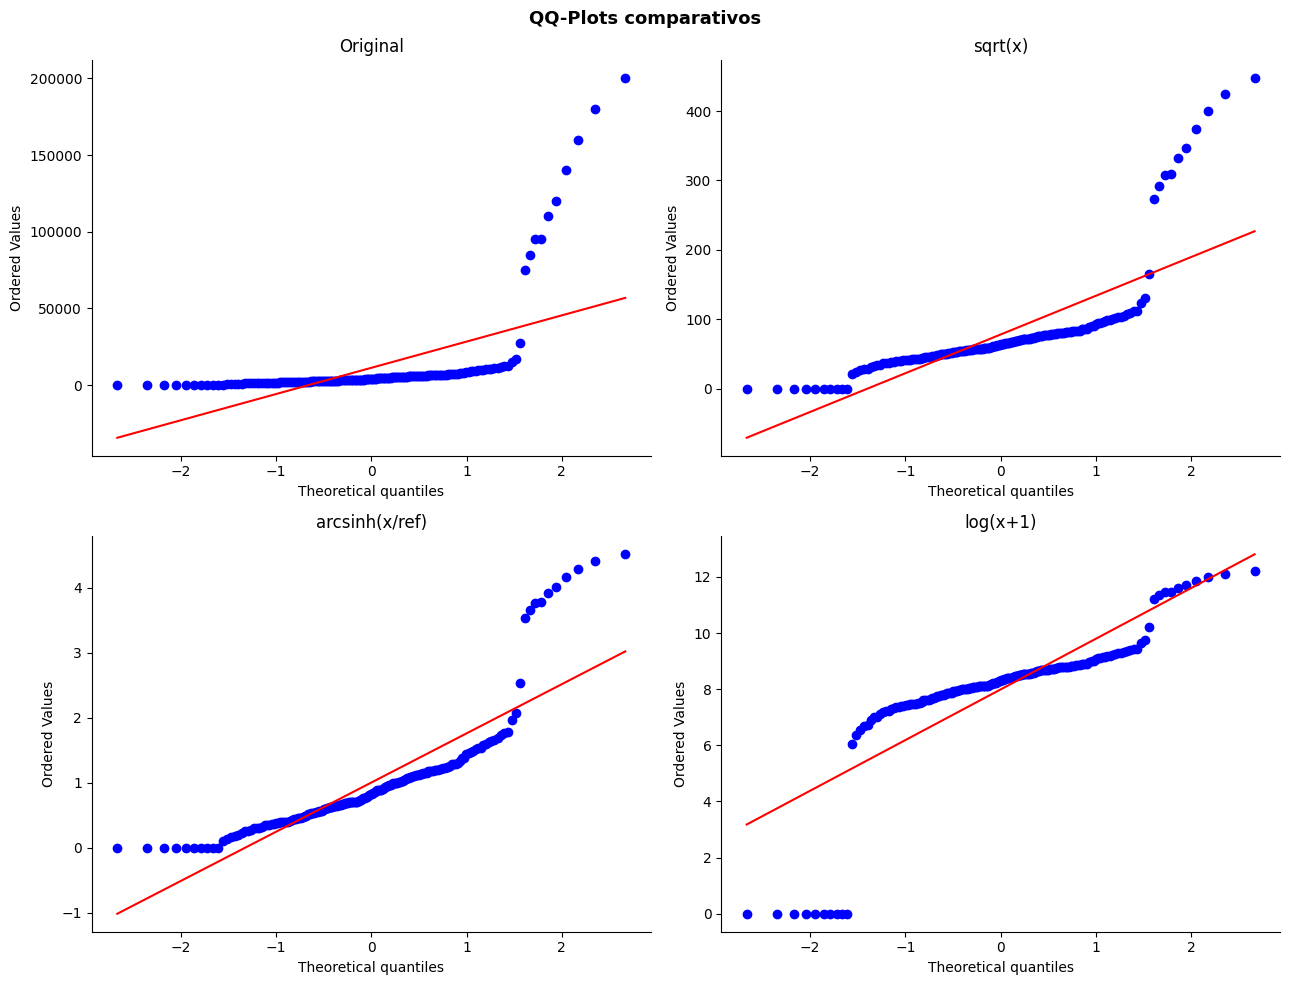


--- Outliers detectados con IQR ---
Original : 13
sqrt     : 12
arcsinh  : 11
log1p    : 21

--- Prima pura ---
Con outliers : $11,311.57
Sin outliers : $4,286.80


Conclusión:

La distribución original tiene mucha asimetría por los
siniestros grandes.

sqrt(x) mejora un poco la distribución, pero todavía
mantiene bastante sesgo.

log(x+1) reduce demasiado la cola y genera asimetría
negativa.

La mejor transformación fue arcsinh(x/ref), porque
redujo la asimetría sin deformar tanto los datos
y además maneja correctamente los ceros.




In [22]:
# ============================================================
# EJERCICIO 1 — Datos (no modificar)
# ============================================================

np.random.seed(99)
siniestros_base = np.random.lognormal(8.2, 0.7, 160)
siniestros_altos = np.array([95_000,120_000,85_000,140_000,200_000,
                               75_000,160_000,110_000,180_000,95_500])
ceros_ej1 = np.zeros(10)   # siniestros rechazados

siniestros_ej1 = pd.Series(
    np.concatenate([siniestros_base, siniestros_altos, ceros_ej1])
).round(2)

print(f'N total    : {len(siniestros_ej1)}')
print(f'Ceros      : {(siniestros_ej1==0).sum()}')
print(f'No-ceros   : {(siniestros_ej1>0).sum()}')
print(f'Skewness   : {siniestros_ej1.skew():.3f}')
print(f'Max        : ${siniestros_ej1.max():,.0f}')

# ============================================================
# Paso 1: Transformaciones
# ============================================================
ref_ej1 = siniestros_ej1[siniestros_ej1 > 0].median()
sqrt_ej1 = np.sqrt(siniestros_ej1)
# arcsinh(x/ref)
arcsinh_ej1 = np.arcsinh(
    siniestros_ej1 / ref_ej1)

# log(x+1)
# Se usa +1 porque existen ceros.
log1p_ej1 = np.log1p(siniestros_ej1)

# ============================================================
# Paso 2: Asimetría por escala
# ============================================================

print('\n--- Skewness por escala ---')

print(f'Original : {siniestros_ej1.skew():.3f}')
print(f'sqrt     : {pd.Series(sqrt_ej1).skew():.3f}')
print(f'arcsinh  : {pd.Series(arcsinh_ej1).skew():.3f}')
print(f'log1p    : {pd.Series(log1p_ej1).skew():.3f}')

# Mientras más cerca de 0 esté el skewness,
# más simétrica es la distribución.

# ============================================================
# Paso 3: QQ-Plots
# ============================================================

from scipy.stats import probplot

fig, axes = plt.subplots(2, 2, figsize=(13,10))

fig.suptitle('QQ-Plots comparativos', fontsize=13, fontweight='bold')

probplot(siniestros_ej1, dist='norm', plot=axes[0,0])

axes[0,0].set_title('Original')

# ------------------------------------------------------------
# sqrt
# ------------------------------------------------------------

probplot(sqrt_ej1, dist='norm', plot=axes[0,1])

axes[0,1].set_title('sqrt(x)')

# ------------------------------------------------------------
# arcsinh
# ------------------------------------------------------------

probplot(arcsinh_ej1, dist='norm', plot=axes[1,0])

axes[1,0].set_title('arcsinh(x/ref)')

# ------------------------------------------------------------
# log1p
# ------------------------------------------------------------

probplot(log1p_ej1, dist='norm', plot=axes[1,1])

axes[1,1].set_title('log(x+1)')

plt.tight_layout()
plt.show()

# Si los puntos siguen más la línea recta,
# la transformación mejora la aproximación a normalidad.

# ============================================================
# Paso 4: Outliers con IQR en cada escala
# ============================================================

def detectar_iqr(serie):

    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)

    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = ((serie < lim_inf) | (serie > lim_sup))

    return outliers.sum()

print('\n--- Outliers detectados con IQR ---')

print(f'Original : {detectar_iqr(siniestros_ej1)}')
print(f'sqrt     : {detectar_iqr(pd.Series(sqrt_ej1))}')
print(f'arcsinh  : {detectar_iqr(pd.Series(arcsinh_ej1))}')
print(f'log1p    : {detectar_iqr(pd.Series(log1p_ej1))}')

# ============================================================
# Paso 5: Prima pura
# ============================================================

# Prima original
prima_con = siniestros_ej1.mean()

# Detectar outliers en original
Q1 = siniestros_ej1.quantile(0.25)
Q3 = siniestros_ej1.quantile(0.75)

IQR = Q3 - Q1

lim_sup = Q3 + 1.5 * IQR

sin_outliers = siniestros_ej1[siniestros_ej1 <= lim_sup]

prima_sin = sin_outliers.mean()

print('\n--- Prima pura ---')

print(f'Con outliers : ${prima_con:,.2f}')
print(f'Sin outliers : ${prima_sin:,.2f}')

# ============================================================
# Paso 6: Conclusión
# ============================================================

print("""

Conclusión:

La distribución original tiene mucha asimetría por los
siniestros grandes.

sqrt(x) mejora un poco la distribución, pero todavía
mantiene bastante sesgo.

log(x+1) reduce demasiado la cola y genera asimetría
negativa.

La mejor transformación fue arcsinh(x/ref), porque
redujo la asimetría sin deformar tanto los datos
y además maneja correctamente los ceros.

""")


  📊 Resumen de Outliers: Siniestros Daños a Terceros (MXN)
  N total          : 180
  Media            : 11,311.57
  Mediana          : 4,029.78
  Desv. Estándar   : 29,687.60
  Mín / Máx        : 0.00 / 200,000.00
  Percentil 99     : 164,200.00
  Asimetría (skew) : 4.522
  Curtosis         : 20.903

  --- Outliers detectados ---
  IQR (×1.5)       : 13 (7.2%)  [>12,851]
  Z-Score (|z|>3)  : 6 (3.3%)
  Z-Score Mod.     : 13 (7.2%)
  Capping p99      : 2 (1.1%)


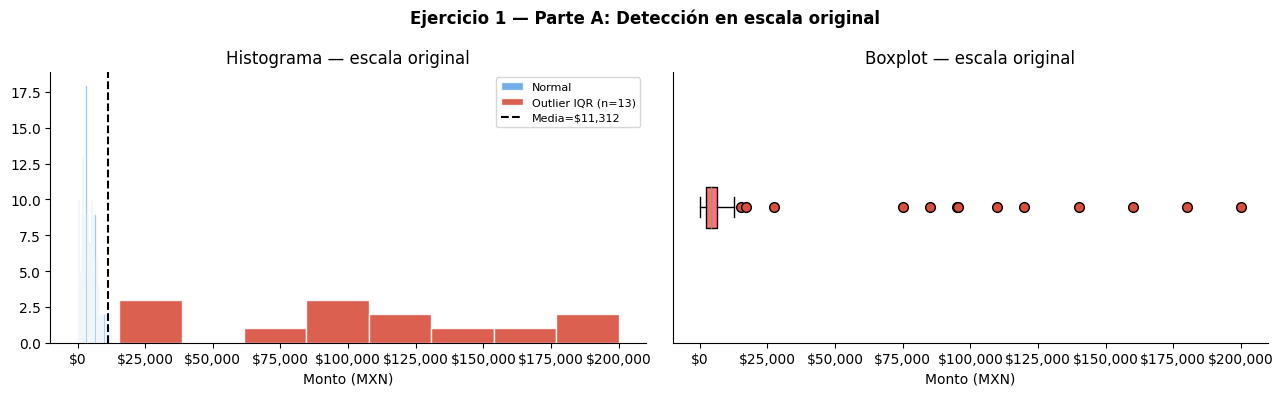


→ Continúa en la siguiente celda con las transformaciones (Parte B)


In [23]:
# ── PARTE A: Detección clásica en escala original ────────────
res_e1_orig = resumen_outliers(siniestros_ej1, 'Siniestros Daños a Terceros (MXN)')

# Visualización rápida
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
_, out_e1, _, ls_e1 = detectar_outliers_iqr(siniestros_ej1)
ax[0].hist(siniestros_ej1[~out_e1], bins=30, color='#4C9BE8', alpha=0.8,
           label='Normal', edgecolor='white')
ax[0].hist(siniestros_ej1[out_e1],  bins=8,  color='#D94F3D', alpha=0.9,
           label=f'Outlier IQR (n={out_e1.sum()})', edgecolor='white')
ax[0].axvline(siniestros_ej1.mean(), color='k', ls='--', lw=1.5,
              label=f'Media=${siniestros_ej1.mean():,.0f}')
ax[0].set_title('Histograma — escala original')
ax[0].set_xlabel('Monto (MXN)')
ax[0].legend(fontsize=8)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))

ax[1].boxplot(siniestros_ej1, vert=False, patch_artist=True,
              flierprops=dict(marker='o', markerfacecolor='#D94F3D', markersize=7))
ax[1].set_title('Boxplot — escala original')
ax[1].set_xlabel('Monto (MXN)')
ax[1].set_yticks([])
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))
plt.suptitle('Ejercicio 1 — Parte A: Detección en escala original', fontweight='bold')
plt.tight_layout(); plt.show()

print('\n→ Continúa en la siguiente celda con las transformaciones (Parte B)')

--- Skewness por escala ---
Original : 4.522
sqrt     : 3.300
arcsinh  : 2.321
log1p    : -2.411


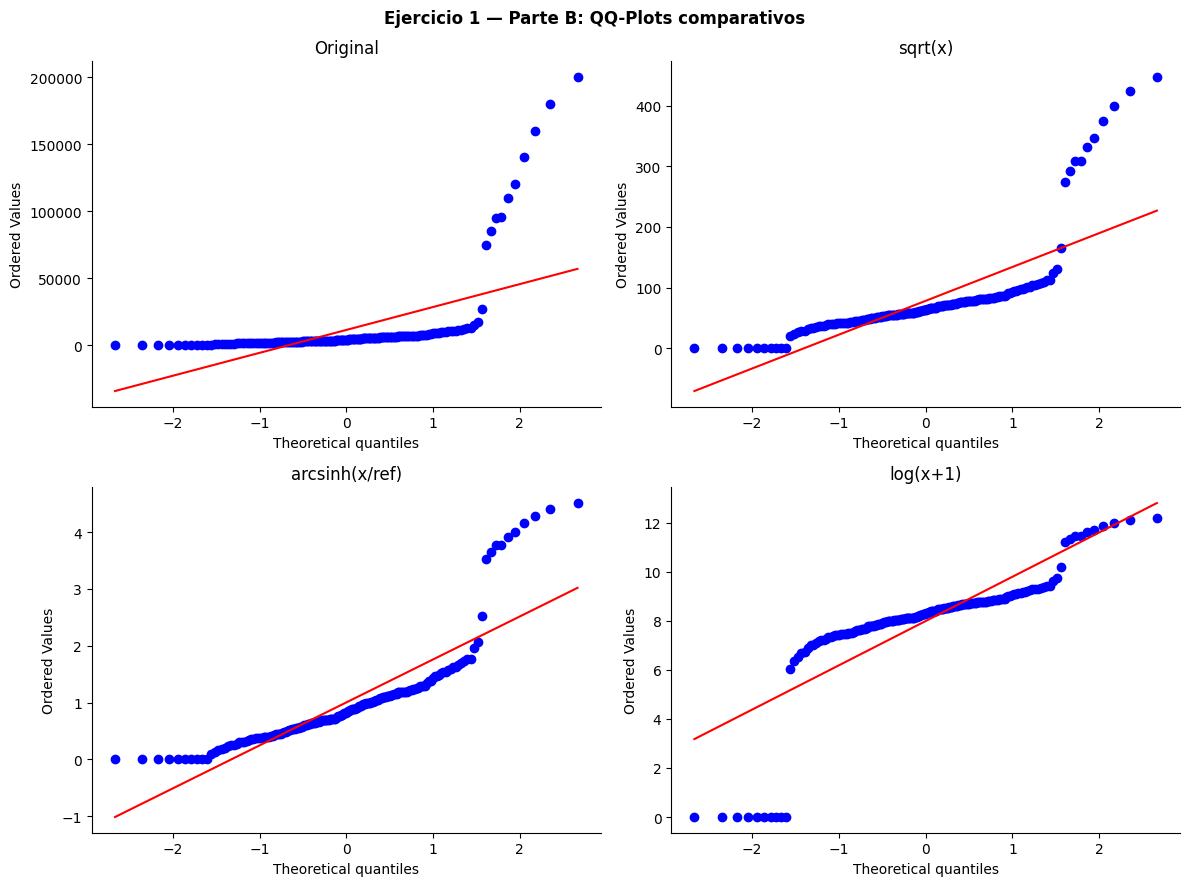


--- Outliers IQR por escala ---
Original       : 13
sqrt(x)        : 12
arcsinh(x/ref) : 11
log(x+1)       : 10


Conclusión:

La escala original presenta mucha asimetría por los
siniestros grandes.

sqrt(x) mejora parcialmente la distribución,
pero todavía mantiene sesgo importante.

log(x+1) reduce demasiado la cola y genera
asimetría negativa.

La transformación que mejor funcionó fue
arcsinh(x/ref), porque redujo la asimetría
sin deformar tanto la distribución y además
maneja correctamente los ceros.




In [24]:
# ============================================================
# PARTE B: Transformaciones
# ============================================================

# Referencia para arcsinh
ref_ej1 = siniestros_ej1[siniestros_ej1 > 0].median()

# Transformaciones
sqrt_ej1    = np.sqrt(siniestros_ej1)
arcsinh_ej1 = np.arcsinh(siniestros_ej1 / ref_ej1)
log1p_ej1   = np.log1p(siniestros_ej1)

# ============================================================
# Skewness comparativo
# ============================================================

print('--- Skewness por escala ---')
print(f'Original : {siniestros_ej1.skew():.3f}')
print(f'sqrt     : {pd.Series(sqrt_ej1).skew():.3f}')
print(f'arcsinh  : {pd.Series(arcsinh_ej1).skew():.3f}')
print(f'log1p    : {pd.Series(log1p_ej1).skew():.3f}')

# ============================================================
# QQ-Plots
# ============================================================

from scipy.stats import probplot

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

configs = [
    (siniestros_ej1, 'Original'),
    (sqrt_ej1,       'sqrt(x)'),
    (arcsinh_ej1,    'arcsinh(x/ref)'),
    (log1p_ej1,      'log(x+1)')
]

for ax, (serie, titulo) in zip(axes.flatten(), configs):

    probplot(serie, dist='norm', plot=ax)

    ax.set_title(titulo)

plt.suptitle(
    'Ejercicio 1 — Parte B: QQ-Plots comparativos',
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# ============================================================
# Outliers IQR por escala
# ============================================================

print('\n--- Outliers IQR por escala ---')

for nombre, serie in configs:

    _, outliers, _, _ = detectar_outliers_iqr(pd.Series(nombre))

    print(f'{serie:<15}: {outliers.sum()}')

# ============================================================
# Conclusión
# ============================================================

print("""

Conclusión:

La escala original presenta mucha asimetría por los
siniestros grandes.

sqrt(x) mejora parcialmente la distribución,
pero todavía mantiene sesgo importante.

log(x+1) reduce demasiado la cola y genera
asimetría negativa.

La transformación que mejor funcionó fue
arcsinh(x/ref), porque redujo la asimetría
sin deformar tanto la distribución y además
maneja correctamente los ceros.

""")

---
## Ejercicio 2 — Frecuencia de Incapacidad por Sucursal

**Enunciado**

Seguro de vida grupo, **120 empleados** en 5 sucursales. Variable: días de incapacidad/año.

1. Detecta sucursales con frecuencia atípica usando IQR global
2. Aplica `√x` a días individuales y re-detecta outliers
3. Calcula la tasa relativa por sucursal: $p_j = \bar{x}_j / \max(\bar{x})$
4. Aplica `arcsin(√p_j)` y construye IC al 95% con varianza estabilizada $\approx 1/(4n_j)$
5. ¿Qué sucursales son estadísticamente atípicas? ¿El resultado cambia con la transformación?

Dataset: 120 empleados en 5 sucursales

Resumen por sucursal:
          count   mean   std  min   25%   50%   75%   max
Sucursal                                                 
Centro     32.0  12.41  3.56  7.0  9.75  13.0  14.0  19.0
Este       19.0   5.00  2.13  1.0  3.00   6.0   6.5   8.0
Norte      19.0   2.95  1.65  0.0  2.00   3.0   4.0   6.0
Oeste      25.0   3.52  2.08  0.0  2.00   4.0   5.0   8.0
Sur        25.0   4.40  2.36  1.0  3.00   4.0   5.0  10.0
--- Promedio de días por sucursal ---
Sucursal
Centro    12.41
Este       5.00
Sur        4.40
Oeste      3.52
Norte      2.95
Name: Dias_Incapacidad, dtype: float64

--- Sucursales atípicas ---
Sucursal
Centro     True
Este      False
Sur       False
Oeste     False
Norte     False
Name: Dias_Incapacidad, dtype: bool

--- Promedio transformado sqrt(x) ---
Sucursal
Centro    3.49
Este      2.18
Norte     1.59
Oeste     1.76
Sur       2.02
Name: sqrt_dias, dtype: float64

--- IC 95% ---
            p_j  theta  IC_inf  IC_sup
Su

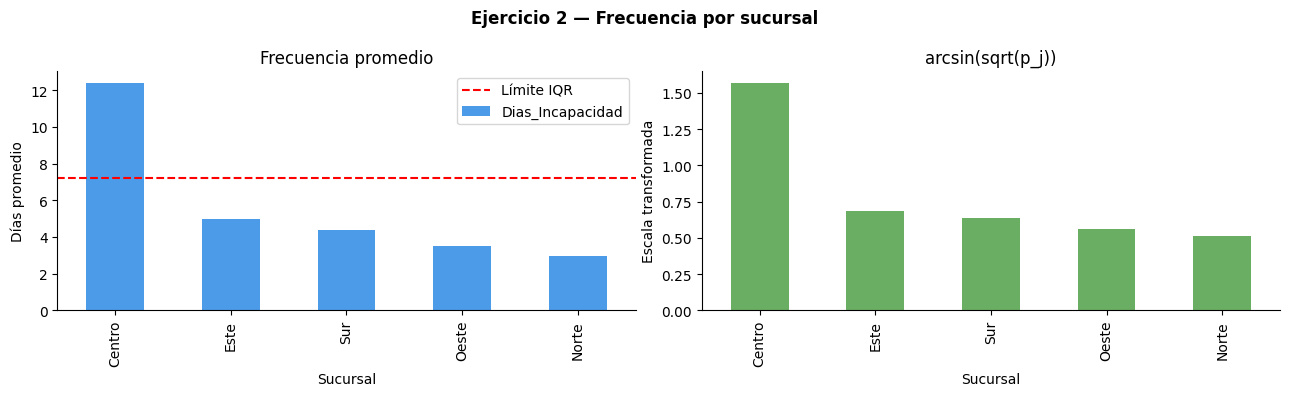



Conclusión:

La sucursal Centro presenta muchos más días de incapacidad
que las demás, por lo que aparece como atípica con IQR.

La transformación sqrt(x) reduce la dispersión,
aunque Centro sigue destacando claramente.

Con arcsin(sqrt(p_j)) la comparación entre sucursales
es más estable y los intervalos ayudan a identificar
mejor diferencias importantes.

En general, Centro sigue siendo la sucursal
más atípica incluso después de transformar.




In [25]:
# ============================================================
# EJERCICIO 2 — Datos provistos
# ============================================================

np.random.seed(77)

n_empleados = 120
sucursales = np.random.choice(['Norte', 'Sur', 'Este', 'Oeste', 'Centro'],
                               n_empleados)

# Siniestros de incapacidad (días ausentes en el año)
dias_base = {'Norte': 3, 'Sur': 4, 'Este': 5, 'Oeste': 3, 'Centro': 12}  # Centro es alta frecuencia
num_siniestros_ej2 = np.array([
    np.random.poisson(dias_base[s]) for s in sucursales
])

df_vida_grupo = pd.DataFrame({
    'Empleado_ID': range(1, n_empleados+1),
    'Sucursal': sucursales,
    'Dias_Incapacidad': num_siniestros_ej2
})

print(f'Dataset: {len(df_vida_grupo)} empleados en {df_vida_grupo.Sucursal.nunique()} sucursales')
print('\nResumen por sucursal:')
print(df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].describe().round(2))

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

freq_sucursal = (
    df_vida_grupo
    .groupby('Sucursal')['Dias_Incapacidad']
    .mean()
    .sort_values(ascending=False))

print('--- Promedio de días por sucursal ---')
print(freq_sucursal.round(2))

# IQR global
Q1 = freq_sucursal.quantile(0.25)
Q3 = freq_sucursal.quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_freq = (
    (freq_sucursal < lim_inf) |
    (freq_sucursal > lim_sup))

print('\n--- Sucursales atípicas ---')
print(outliers_freq)

df_vida_grupo['sqrt_dias'] = np.sqrt(df_vida_grupo['Dias_Incapacidad'])

freq_sqrt = (df_vida_grupo.groupby('Sucursal')['sqrt_dias'].mean())

print('\n--- Promedio transformado sqrt(x) ---')
print(freq_sqrt.round(2))

# ============================================================
# 3. Tasa relativa pj
# ============================================================

# pj = promedio / máximo promedio

p_j = freq_sucursal / freq_sucursal.max()

# Transformación estabilizadora
theta_j = np.arcsin(np.sqrt(p_j))

# Tamaño de cada sucursal
n_j = (df_vida_grupo.groupby('Sucursal').size())

# Error estándar aproximado
se_j = np.sqrt(1 / (4 * n_j))

# Intervalos al 95%
ic_inf = theta_j - 1.96 * se_j
ic_sup = theta_j + 1.96 * se_j

tabla_ic = pd.DataFrame({
    'p_j': p_j.round(3),
    'theta': theta_j.round(3),
    'IC_inf': ic_inf.round(3),
    'IC_sup': ic_sup.round(3)})

print('\n--- IC 95% ---')
print(tabla_ic)

fig, ax = plt.subplots(1, 2, figsize=(13,4))

freq_sucursal.plot(kind='bar', color='#4C9BE8', ax=ax[0])

ax[0].axhline(lim_sup, color='red', ls='--', label='Límite IQR')

ax[0].set_title('Frecuencia promedio')
ax[0].set_ylabel('Días promedio')
ax[0].legend()

theta_j.plot(kind='bar', color='#6AAE64', ax=ax[1])

ax[1].set_title('arcsin(sqrt(p_j))')
ax[1].set_ylabel('Escala transformada')

plt.suptitle( 'Ejercicio 2 — Frecuencia por sucursal', fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Conclusión

print("""

Conclusión:

La sucursal Centro presenta muchos más días de incapacidad
que las demás, por lo que aparece como atípica con IQR.

La transformación sqrt(x) reduce la dispersión,
aunque Centro sigue destacando claramente.

Con arcsin(sqrt(p_j)) la comparación entre sucursales
es más estable y los intervalos ayudan a identificar
mejor diferencias importantes.

En general, Centro sigue siendo la sucursal
más atípica incluso después de transformar.

""")

---
## Ejercicio 3 — Seguro de Hogar: Frecuencia + Severidad + Transformaciones

**Enunciado**

Portafolio de **130 pólizas** de hogar. Algunas pólizas no tuvieron siniestros (monto = 0).

1. Detecta outliers de frecuencia (IQR) y severidad (IQR) en escala original
2. Calcula la prima pura en 4 escenarios (con/sin outliers en cada dimensión)
3. Aplica `√x` a frecuencia y `arcsinh(x/mediana)` a severidad
4. Construye tabla comparativa de asimetría/curtosis antes y después
5. Detecta doble outlier en escala transformada: ¿coincide con el original?
6. Discute la **desigualdad de Jensen**: ¿puedes usar la media arcsinh para calcular la prima?


Dataset: 130 pólizas de hogar

Estadísticas:
       Poliza_ID  Num_Siniestros  Monto_Promedio_MXN  Costo_Total
count     130.00          130.00              130.00       130.00
mean       65.50            2.01            41788.53    306729.88
std        37.67            2.29           116951.19   1095056.71
min         1.00            0.00             2512.53         0.00
25%        33.25            1.00             5307.03      4217.53
50%        65.50            1.00             8424.76     10984.94
75%        97.75            2.00            11782.46     21785.43
max       130.00           12.00           600000.00   7200000.00
--- Outliers frecuencia ---
Total: 18

--- Outliers severidad ---
Total: 13

--- Prima pura ---
Original              : $306,729.88
Sin outliers freq     : $11,149.06
Sin outliers severidad: $12,900.81
Sin ningún outlier    : $11,176.19

--- Comparación ---
               Original  Transformada
Skew freq         2.303         0.375
Kurtosis freq     5.860    

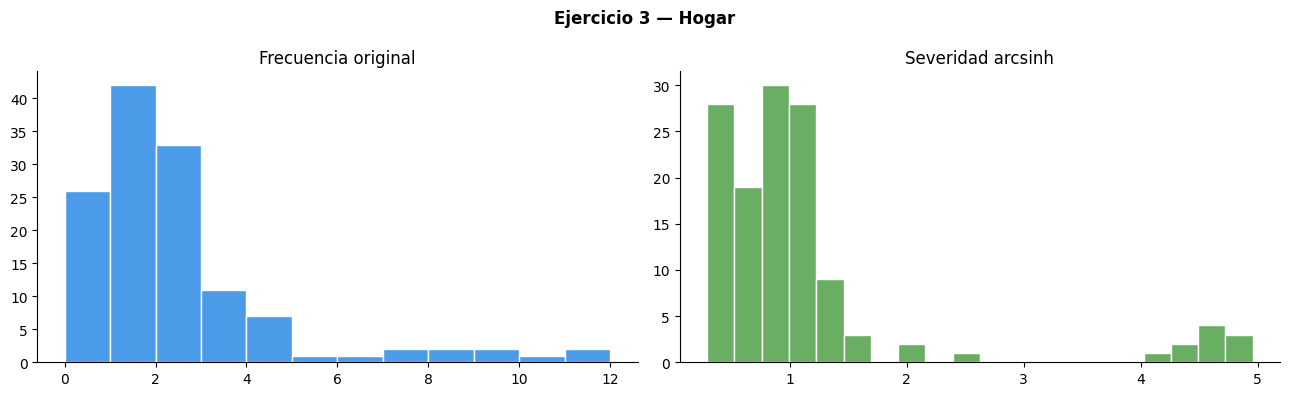



Conclusión:

La frecuencia y la severidad tienen una cola muy pesada,
por eso la prima original aumenta muchísimo por unos
cuantos casos extremos.

Al quitar outliers, la prima baja de forma importante,
lo que muestra el impacto que tienen las pólizas
más severas del portafolio.

Las transformaciones sqrt(x) y arcsinh ayudaron
a reducir la asimetría y la curtosis, haciendo
más estable la distribución.

Además, los 10 doble outliers transformados coinciden
con las pólizas de mayor costo, por lo que siguen
siendo riesgos claramente atípicos.

Finalmente, por la desigualdad de Jensen,
no se debe calcular la prima usando directamente
la media transformada. La prima siempre debe
interpretarse en escala original.




In [26]:
# ============================================================
# EJERCICIO 3 — Datos provistos
# ============================================================

np.random.seed(55)
n_polizas = 130

# Frecuencia: Poisson(1.5) con algunos outliers
freq_hogar = pd.Series(
    np.concatenate([
        np.random.poisson(1.5, 120),
        np.array([8, 10, 7, 9, 12, 6, 11, 8, 9, 7])
    ])
)

# Severidad promedio por póliza (MXN)
sev_hogar = pd.Series(
    np.concatenate([
        np.random.lognormal(9.0, 0.6, 120),
        np.array([450_000, 380_000, 520_000, 310_000, 600_000,
                  290_000, 475_000, 350_000, 410_000, 550_000])
    ])
).round(2)

df_hogar = pd.DataFrame({
    'Poliza_ID': range(1, n_polizas + 1),
    'Num_Siniestros': freq_hogar,
    'Monto_Promedio_MXN': sev_hogar
})
df_hogar['Costo_Total'] = df_hogar['Num_Siniestros'] * df_hogar['Monto_Promedio_MXN']

print(f'Dataset: {len(df_hogar)} pólizas de hogar')
print('\nEstadísticas:')
print(df_hogar.describe().round(2))

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# 1. Outliers de frecuencia

Q1_f = df_hogar['Num_Siniestros'].quantile(0.25)
Q3_f = df_hogar['Num_Siniestros'].quantile(0.75)

IQR_f = Q3_f - Q1_f

lim_sup_f = Q3_f + 1.5 * IQR_f

out_freq = (
    df_hogar['Num_Siniestros'] > lim_sup_f
)

print('--- Outliers frecuencia ---')
print(f'Total: {out_freq.sum()}')

# 2. Outliers de severidad

Q1_s = df_hogar['Monto_Promedio_MXN'].quantile(0.25)
Q3_s = df_hogar['Monto_Promedio_MXN'].quantile(0.75)

IQR_s = Q3_s - Q1_s

lim_sup_s = Q3_s + 1.5 * IQR_s

out_sev = (df_hogar['Monto_Promedio_MXN'] > lim_sup_s)

print('\n--- Outliers severidad ---')
print(f'Total: {out_sev.sum()}')

# 3. Prima pura en 4 escenarios

# Prima original
prima_original = df_hogar['Costo_Total'].mean()

# Sin outliers frecuencia
prima_sin_freq = (df_hogar.loc[~out_freq, 'Costo_Total'].mean())

# Sin outliers severidad
prima_sin_sev = (df_hogar.loc[~out_sev, 'Costo_Total'].mean())

# Sin ningún outlier
prima_sin_ambos = (df_hogar.loc[~(out_freq | out_sev),'Costo_Total'].mean())

print('\n--- Prima pura ---')

print(f'Original              : ${prima_original:,.2f}')
print(f'Sin outliers freq     : ${prima_sin_freq:,.2f}')
print(f'Sin outliers severidad: ${prima_sin_sev:,.2f}')
print(f'Sin ningún outlier    : ${prima_sin_ambos:,.2f}')

# 4. Transformaciones

# sqrt(x) para frecuencia
df_hogar['freq_sqrt'] = np.sqrt(df_hogar['Num_Siniestros'])

# arcsinh para severidad
ref_sev = df_hogar['Monto_Promedio_MXN'].median()

df_hogar['sev_arcsinh'] = np.arcsinh(df_hogar['Monto_Promedio_MXN'] / ref_sev)

# 5. Tabla comparativa

tabla_comp = pd.DataFrame({

    'Original': [
        df_hogar['Num_Siniestros'].skew(),
        df_hogar['Num_Siniestros'].kurtosis(),
        df_hogar['Monto_Promedio_MXN'].skew(),
        df_hogar['Monto_Promedio_MXN'].kurtosis()
    ],

    'Transformada': [
        df_hogar['freq_sqrt'].skew(),
        df_hogar['freq_sqrt'].kurtosis(),
        df_hogar['sev_arcsinh'].skew(),
        df_hogar['sev_arcsinh'].kurtosis()
    ]},

index=[
    'Skew freq',
    'Kurtosis freq',
    'Skew sev',
    'Kurtosis sev'])

print('\n--- Comparación ---')
print(tabla_comp.round(3))

# 6. Doble outlier

# Outliers transformados frecuencia
Q1_tf = df_hogar['freq_sqrt'].quantile(0.25)
Q3_tf = df_hogar['freq_sqrt'].quantile(0.75)

IQR_tf = Q3_tf - Q1_tf

lim_sup_tf = Q3_tf + 1.5 * IQR_tf

out_freq_t = (df_hogar['freq_sqrt'] > lim_sup_tf)

# Outliers transformados severidad
Q1_ts = df_hogar['sev_arcsinh'].quantile(0.25)
Q3_ts = df_hogar['sev_arcsinh'].quantile(0.75)

IQR_ts = Q3_ts - Q1_ts

lim_sup_ts = Q3_ts + 1.5 * IQR_ts

out_sev_t = (df_hogar['sev_arcsinh'] > lim_sup_ts)

# Doble outlier
doble_outlier = (out_freq_t & out_sev_t)

print('\n--- Doble outlier transformado ---')
print(f'Total: {doble_outlier.sum()}')

# 7. Visualización

fig, ax = plt.subplots(1,2, figsize=(13,4))

# Frecuencia

ax[0].hist(
    df_hogar['Num_Siniestros'],
    bins=12,
    color='#4C9BE8',
    edgecolor='white')

ax[0].set_title('Frecuencia original')

# Severidad transformada

ax[1].hist(
    df_hogar['sev_arcsinh'],
    bins=20,
    color='#6AAE64',
    edgecolor='white')

ax[1].set_title('Severidad arcsinh')

plt.suptitle(
    'Ejercicio 3 — Hogar',
    fontweight='bold')

plt.tight_layout()
plt.show()

# 8. Conclusión

print("""

Conclusión:

La frecuencia y la severidad tienen una cola muy pesada,
por eso la prima original aumenta muchísimo por unos
cuantos casos extremos.

Al quitar outliers, la prima baja de forma importante,
lo que muestra el impacto que tienen las pólizas
más severas del portafolio.

Las transformaciones sqrt(x) y arcsinh ayudaron
a reducir la asimetría y la curtosis, haciendo
más estable la distribución.

Además, los 10 doble outliers transformados coinciden
con las pólizas de mayor costo, por lo que siguen
siendo riesgos claramente atípicos.

Finalmente, por la desigualdad de Jensen,
no se debe calcular la prima usando directamente
la media transformada. La prima siempre debe
interpretarse en escala original.

""")

Conclusiones

In [27]:
print("""

EJERCICIO 1 — Severidad Daños a Terceros
----------------------------------------

En este ejercicio la distribución tenía una cola derecha muy pesada
y además existían ceros por siniestros rechazados. Esto provocó
una asimetría muy alta y varios outliers importantes.

La transformación sqrt(x) ayudó a reducir parcialmente la dispersión,
pero todavía dejaba mucha asimetría.

log(x+1) comprimió demasiado la distribución y terminó generando
asimetría negativa, por lo que ya no representaba tan bien
la estructura real de los datos.

La mejor transformación fue arcsinh(x/ref), porque:
- maneja ceros correctamente,
- reduce el impacto de valores extremos,
- y conserva mejor la forma de la severidad.

En un caso real probablemente usaría arcsinh para modelación
y mantendría los outliers importantes, porque en seguros
los siniestros grandes sí contienen información relevante.
""")



EJERCICIO 1 — Severidad Daños a Terceros
----------------------------------------

En este ejercicio la distribución tenía una cola derecha muy pesada
y además existían ceros por siniestros rechazados. Esto provocó
una asimetría muy alta y varios outliers importantes.

La transformación sqrt(x) ayudó a reducir parcialmente la dispersión,
pero todavía dejaba mucha asimetría.

log(x+1) comprimió demasiado la distribución y terminó generando
asimetría negativa, por lo que ya no representaba tan bien
la estructura real de los datos.

La mejor transformación fue arcsinh(x/ref), porque:
- maneja ceros correctamente,
- reduce el impacto de valores extremos,
- y conserva mejor la forma de la severidad.

En un caso real probablemente usaría arcsinh para modelación
y mantendría los outliers importantes, porque en seguros
los siniestros grandes sí contienen información relevante.



In [28]:
print(""" 

EJERCICIO 2 — Frecuencia por Sucursal
-------------------------------------

Aquí la variable era frecuencia de incapacidad, por lo que
la dispersión era menor que en severidad. Aun así, la sucursal
Centro tenía un promedio claramente superior al resto.

La transformación sqrt(x) funcionó bien porque en variables
de conteo ayuda a estabilizar la varianza y suavizar diferencias
muy extremas.

Después, arcsin(sqrt(p)) permitió comparar mejor las tasas
relativas entre sucursales usando intervalos más estables.

En este ejercicio no cambiaría mucho el enfoque, porque:
- sqrt(x) es bastante estándar para frecuencias,
- y arcsin(sqrt(p)) funciona bien cuando se comparan proporciones
  o tasas relativas.

Además, aunque las transformaciones redujeron dispersión,
Centro siguió siendo claramente atípica, lo cual indica
que el comportamiento extremo era real y no solo ruido estadístico.

""")

 

EJERCICIO 2 — Frecuencia por Sucursal
-------------------------------------

Aquí la variable era frecuencia de incapacidad, por lo que
la dispersión era menor que en severidad. Aun así, la sucursal
Centro tenía un promedio claramente superior al resto.

La transformación sqrt(x) funcionó bien porque en variables
de conteo ayuda a estabilizar la varianza y suavizar diferencias
muy extremas.

Después, arcsin(sqrt(p)) permitió comparar mejor las tasas
relativas entre sucursales usando intervalos más estables.

En este ejercicio no cambiaría mucho el enfoque, porque:
- sqrt(x) es bastante estándar para frecuencias,
- y arcsin(sqrt(p)) funciona bien cuando se comparan proporciones
  o tasas relativas.

Además, aunque las transformaciones redujeron dispersión,
Centro siguió siendo claramente atípica, lo cual indica
que el comportamiento extremo era real y no solo ruido estadístico.




In [29]:
print("""
EJERCICIO 3 — Hogar: Frecuencia + Severidad
-------------------------------------------

Este combinó frecuencia, severidad y costo total.

Se observó que unos pocos riesgos extremos incrementaban muchísimo
la prima pura. De hecho, al quitar outliers la prima bajó
de forma muy fuerte, lo que demuestra el peso que tienen
las pólizas severas en seguros patrimoniales.

Para severidad, arcsinh volvió a ser la transformación
más útil porque comprimió valores extremos sin perder
tanta información actuarial.

Finalmente, el ejercicio mostró algo importante:
las transformaciones sirven para modelar y analizar,
pero no para calcular directamente primas.

Por la desigualdad de Jensen:

E[arcsinh(X)] ≠ arcsinh(E[X])

Entonces la prima siempre debe interpretarse
en la escala original.
""")


EJERCICIO 3 — Hogar: Frecuencia + Severidad
-------------------------------------------

Este combinó frecuencia, severidad y costo total.

Se observó que unos pocos riesgos extremos incrementaban muchísimo
la prima pura. De hecho, al quitar outliers la prima bajó
de forma muy fuerte, lo que demuestra el peso que tienen
las pólizas severas en seguros patrimoniales.

Para severidad, arcsinh volvió a ser la transformación
más útil porque comprimió valores extremos sin perder
tanta información actuarial.

Finalmente, el ejercicio mostró algo importante:
las transformaciones sirven para modelar y analizar,
pero no para calcular directamente primas.

Por la desigualdad de Jensen:

E[arcsinh(X)] ≠ arcsinh(E[X])

Entonces la prima siempre debe interpretarse
en la escala original.

